# Notebook 01 - EDA (Phân tích dữ liệu khám phá)

Notebook này đọc dữ liệu thô, gán nhãn cảm xúc tổng thể từ nhãn aspect-based và khảo sát các phân phối quan trọng trước khi tiền xử lý sâu.

## 0. Khởi tạo môi trường

Cell này đưa working directory về thư mục gốc project để các đường dẫn như `datasets/raw/Train.csv` luôn hoạt động dù mở notebook từ thư mục nào.

In [1]:
from pathlib import Path
import os
import sys
import warnings

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = Path("results/figures")
CSV_DIR = Path("results/csv")
MODEL_DIR = Path("results/models")
for path in [FIG_DIR, CSV_DIR, MODEL_DIR, Path("datasets/cleaned")]:
    path.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

## 1.1 Tổng quan dataset

Đọc `Train.csv` và `Test.csv`, sau đó xem kích thước, kiểu dữ liệu, số lượng giá trị thiếu và 5 dòng đầu để hiểu cấu trúc dữ liệu.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

from src.preprocessing import add_sentiment_columns, add_aspect_columns, read_filestopwords, full_pipeline
from src.visualization import plot_label_distribution, plot_star_vs_sentiment, plot_top_words

train_raw = pd.read_csv("datasets/raw/Train.csv", encoding="utf-8")
test_raw = pd.read_csv("datasets/raw/Test.csv", encoding="utf-8")

print("Train shape:", train_raw.shape)
print("Test shape :", test_raw.shape)
print("\nKiểu dữ liệu Train:")
display(train_raw.dtypes)
print("\nMissing values Train:")
display(train_raw.isna().sum())
print("\n5 dòng đầu Train:")
display(train_raw.head())

Train shape: (7786, 5)
Test shape : (2224, 5)

Kiểu dữ liệu Train:


index        int64
comment        str
n_star       int64
date_time      str
label          str
dtype: object


Missing values Train:


index        0
comment      0
n_star       0
date_time    0
label        0
dtype: int64


5 dòng đầu Train:


,index,comment,n_star,date_time,label
0,0,Mới mua máy này Tại thegioididong thốt nốt cảm...,5,2 tuần trước,{CAMERA#Positive};{FEATURES#Positive};{BATTERY...
1,1,Pin kém còn lại miễn chê mua 8/3/2019 tình trạ...,5,14/09/2019,{BATTERY#Negative};{GENERAL#Positive};{OTHERS};
2,2,Sao lúc gọi điện thoại màn hình bị chấm nhỏ nh...,3,17/08/2020,{FEATURES#Negative};
3,3,"Mọi người cập nhật phần mềm lại , nó sẽ bớt tố...",3,29/02/2020,{FEATURES#Negative};{BATTERY#Neutral};{GENERAL...
4,4,"Mới mua Sài được 1 tháng thấy pin rất trâu, Sà...",5,4/6/2020,{BATTERY#Positive};{PERFORMANCE#Positive};{SER...


**Ý nghĩa các cột**

- `index`: mã dòng từ dữ liệu gốc.
- `comment`: nội dung bình luận của khách hàng.
- `n_star`: số sao đánh giá từ 1 đến 5.
- `date_time`: thời điểm bình luận.
- `label`: nhãn aspect-based, mỗi nhãn có dạng `{ASPECT#Sentiment}`.

## 1.2 Phân phối nhãn cảm xúc

Dữ liệu gốc có nhãn theo từng aspect, vì vậy cần đếm số Positive, Negative, Neutral trong mỗi dòng rồi gán một nhãn tổng thể `sentiment`.

,label,count,percentage
0,Positive,4008,51.48
1,Negative,2966,38.09
2,Neutral,812,10.43


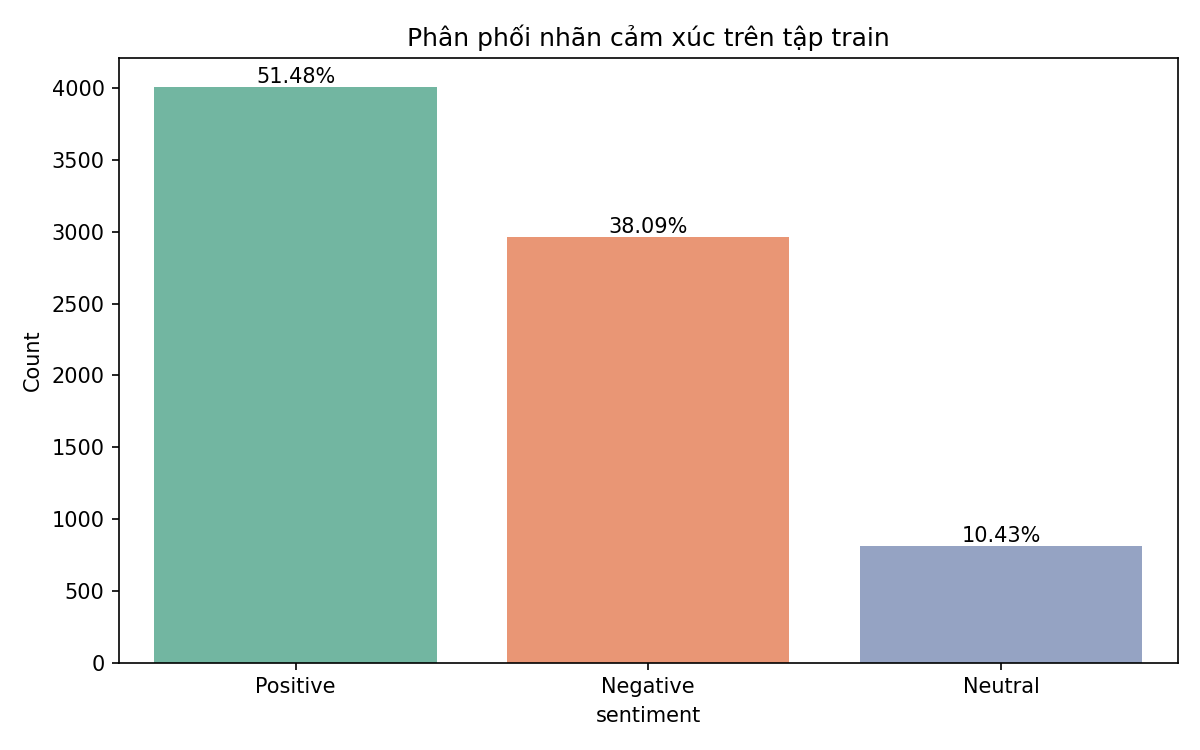

Nhãn lớn nhất chiếm 51.48%, nhãn nhỏ nhất chiếm 10.43%.
Nhận xét: Dataset có dấu hiệu mất cân bằng, mô hình dễ thiên về nhãn phổ biến; nên dùng class_weight hoặc F1 Macro khi đánh giá.


In [3]:
train_eda = add_aspect_columns(add_sentiment_columns(train_raw))
test_eda = add_aspect_columns(add_sentiment_columns(test_raw))

sentiment_dist = plot_label_distribution(
    train_eda, "sentiment", "Phân phối nhãn cảm xúc trên tập train", FIG_DIR / "eda_sentiment_distribution.png"
)
display(sentiment_dist)
display(Image(filename=str(FIG_DIR / "eda_sentiment_distribution.png")))

majority_pct = sentiment_dist["percentage"].max()
minority_pct = sentiment_dist["percentage"].min()
print(f"Nhãn lớn nhất chiếm {majority_pct:.2f}%, nhãn nhỏ nhất chiếm {minority_pct:.2f}%.")
if majority_pct - minority_pct > 20:
    print("Nhận xét: Dataset có dấu hiệu mất cân bằng, mô hình dễ thiên về nhãn phổ biến; nên dùng class_weight hoặc F1 Macro khi đánh giá.")
else:
    print("Nhận xét: Dataset không quá lệch giữa các nhãn chính, nhưng vẫn nên dùng F1 Macro để đánh giá công bằng.")

## 1.3 Phân phối `n_star`

Phần này kiểm tra số sao và cảm xúc có đi cùng nhau không. Nếu 1 sao chủ yếu là Negative và 5 sao chủ yếu là Positive thì `n_star` có tương quan rõ với sentiment.

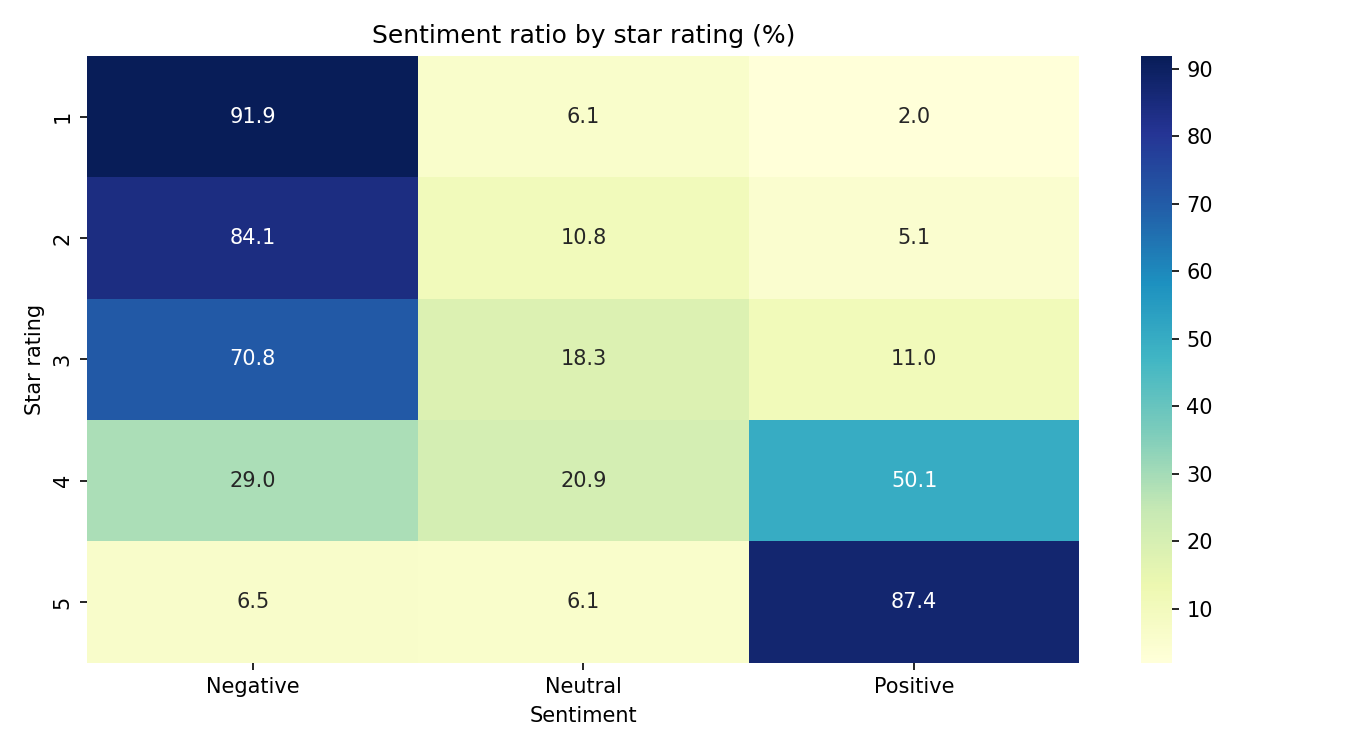

sentiment,Negative,Neutral,Positive
n_star,,,
1,91.90,6.06,2.05
2,84.13,10.76,5.11
3,70.75,18.28,10.97
4,28.99,20.93,50.08
5,6.49,6.10,87.41


1 sao: cảm xúc phổ biến nhất là Negative (91.90%).
2 sao: cảm xúc phổ biến nhất là Negative (84.13%).
3 sao: cảm xúc phổ biến nhất là Negative (70.75%).
4 sao: cảm xúc phổ biến nhất là Positive (50.08%).
5 sao: cảm xúc phổ biến nhất là Positive (87.41%).
Nhận xét: Nếu tỷ lệ Positive tăng theo số sao và Negative giảm theo số sao thì `n_star` phản ánh khá tốt cảm xúc tổng thể.


In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_eda, x="n_star", palette="Set2")
plt.title("Phân phối số sao trên tập train")
plt.xlabel("Số sao")
plt.ylabel("Số lượng bình luận")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_star_distribution.png", dpi=150)
plt.show()

star_sentiment = plot_star_vs_sentiment(train_eda, FIG_DIR / "eda_star_vs_sentiment.png")
display(Image(filename=str(FIG_DIR / "eda_star_vs_sentiment.png")))
display(star_sentiment.round(2))
for star in sorted(train_eda["n_star"].dropna().unique()):
    top_sentiment = star_sentiment.loc[star].idxmax()
    top_pct = star_sentiment.loc[star].max()
    print(f"{star} sao: cảm xúc phổ biến nhất là {top_sentiment} ({top_pct:.2f}%).")
print("Nhận xét: Nếu tỷ lệ Positive tăng theo số sao và Negative giảm theo số sao thì `n_star` phản ánh khá tốt cảm xúc tổng thể.")

## 1.4 Phân phối độ dài bình luận

Độ dài được tính theo số ký tự và số từ. So sánh theo sentiment giúp xem bình luận tiêu cực có xu hướng dài hơn vì người dùng mô tả lỗi chi tiết hơn hay không.

In [5]:
train_eda["char_len"] = train_eda["comment"].astype(str).str.len()
train_eda["word_len"] = train_eda["comment"].astype(str).str.split().str.len()

length_summary = train_eda.groupby("sentiment")[["char_len", "word_len"]].agg(["min", "max", "mean", "median"]).round(2)
display(length_summary)

plt.figure(figsize=(10, 5))
sns.histplot(data=train_eda, x="word_len", hue="sentiment", bins=50, kde=True, element="step")
plt.title("Phân phối độ dài bình luận theo số từ")
plt.xlabel("Số từ")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_comment_length_histogram.png", dpi=150)
plt.show()

mean_words = train_eda.groupby("sentiment")["word_len"].mean().sort_values(ascending=False)
display(mean_words.round(2))
print(f"Nhận xét: Nhóm có độ dài trung bình cao nhất là {mean_words.index[0]} với {mean_words.iloc[0]:.2f} từ/bình luận.")

char_len                     word_len                   
               min  max    mean median      min  max   mean median
sentiment                                                         
Negative        25  846  160.14  131.0        4  194  36.91   31.0
Neutral         39  781  159.96  131.0        8  161  36.79   30.0
Positive        10  785  158.78  127.0        3  176  35.79   29.0

sentiment
Negative    36.91
Neutral     36.79
Positive    35.79
Name: word_len, dtype: float64

Nhận xét: Nhóm có độ dài trung bình cao nhất là Negative với 36.91 từ/bình luận.


## 1.5 Phân phối aspect label

Mỗi bình luận có thể chứa nhiều aspect. Cell này bung tất cả aspect để xem khách hàng nhắc đến khía cạnh nào nhiều nhất.

In [6]:
aspect_counts = train_eda["aspects_list"].explode().dropna().apply(lambda x: x[0]).value_counts()
display(aspect_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette="viridis")
plt.title("Tần suất các aspect trong tập train")
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Aspect")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_aspect_distribution.png", dpi=150)
plt.show()

print(f"Nhận xét: Aspect được nhắc nhiều nhất là {aspect_counts.index[0]} với {aspect_counts.iloc[0]} lượt, cho thấy đây là khía cạnh khách hàng quan tâm nhiều nhất.")

aspects_list
GENERAL        4866
PERFORMANCE    4140
BATTERY        3604
FEATURES       2642
CAMERA         2146
PRICE          2061
SER&ACC        1995
DESIGN         1378
SCREEN          949
STORAGE          91
Name: count, dtype: int64

Nhận xét: Aspect được nhắc nhiều nhất là GENERAL với 4866 lượt, cho thấy đây là khía cạnh khách hàng quan tâm nhiều nhất.


## 1.6 Top 20 từ xuất hiện nhiều nhất

Trước khi đếm từ, bình luận được chạy qua pipeline tiền xử lý để loại stopwords và token hóa tiếng Việt. Sau đó tách riêng top từ của Positive và Negative.

,word,count
0,number,3029
1,máy,2710
2,pin,2328
3,mua,1853
4,tốt,1714
5,đẹp,1423
6,game,1361
7,mượt,1356
8,ok,1313
9,mình,1253


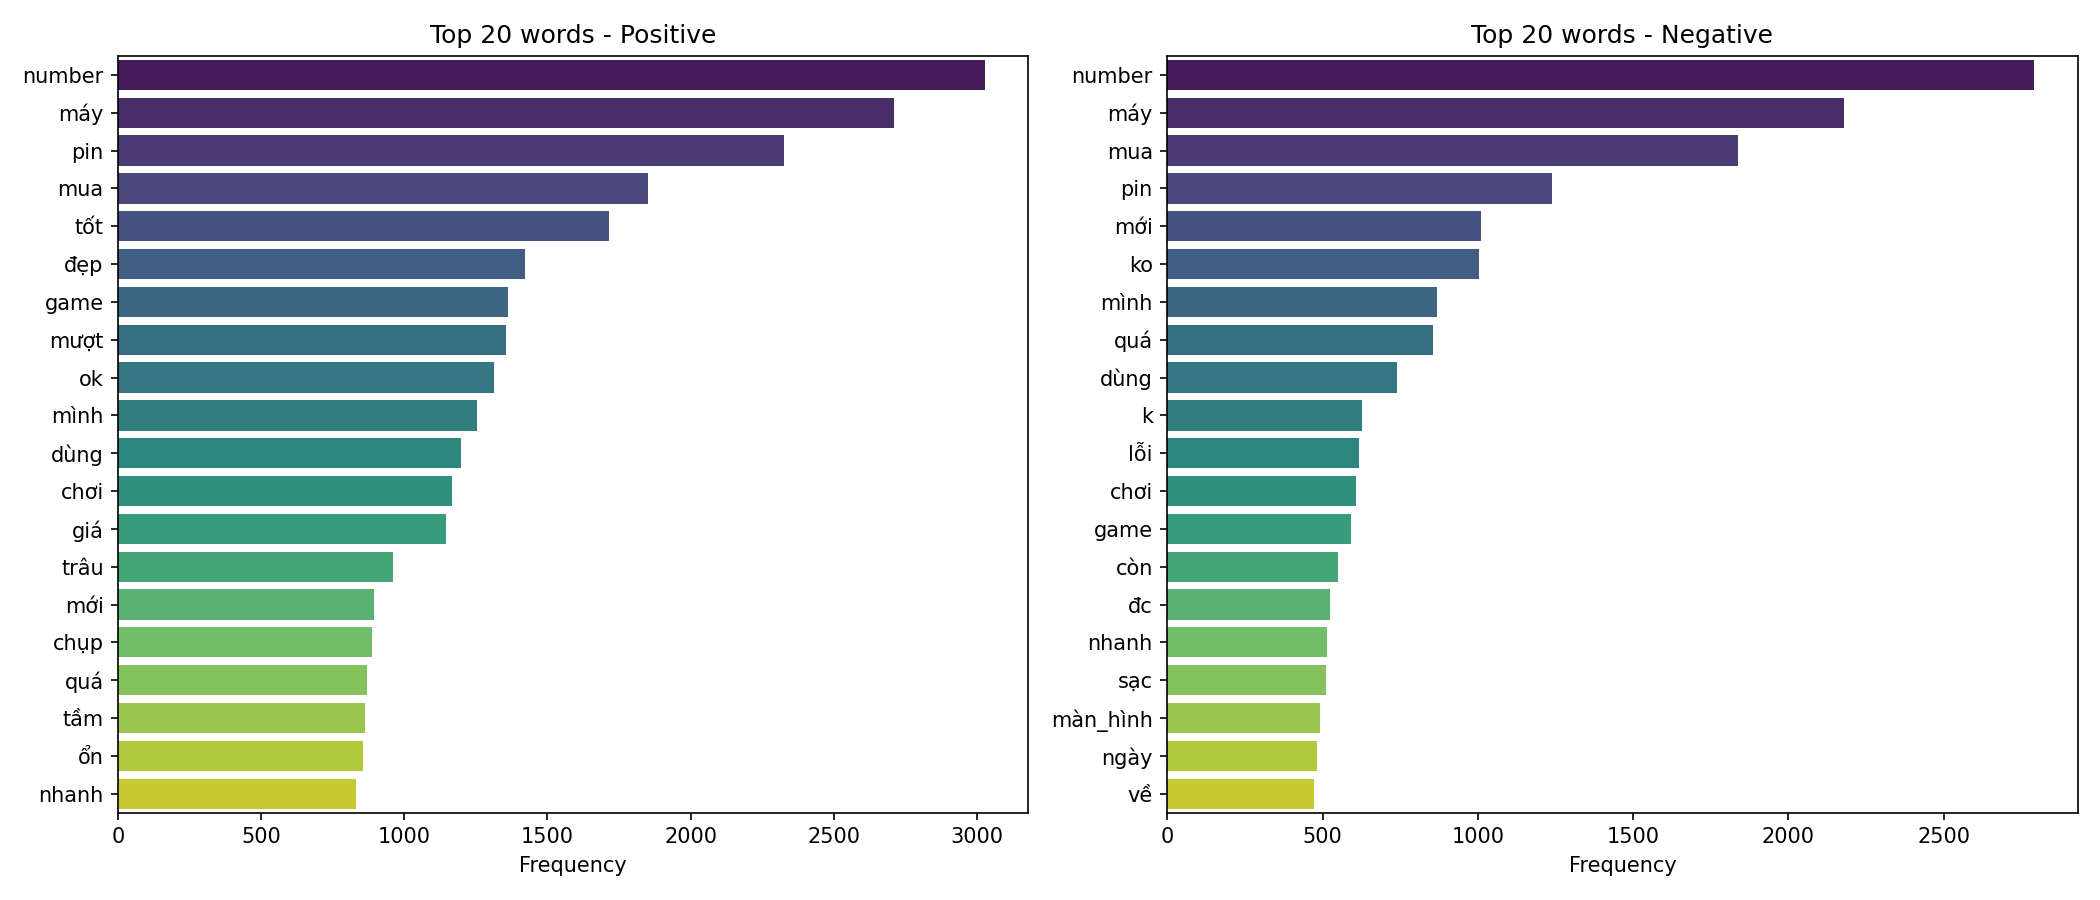

,word,count
0,number,2792
1,máy,2179
2,mua,1837
3,pin,1240
4,mới,1010
5,ko,1003
6,mình,868
7,quá,856
8,dùng,740
9,k,628


Từ nổi bật riêng của Positive: ['game', 'mượt', 'ok', 'tốt', 'đẹp']
Từ nổi bật riêng của Negative: ['dùng', 'k', 'ko', 'mới', 'quá']
Nhận xét: Các từ top giúp nhận diện dấu hiệu cảm xúc; nhóm Negative thường chứa từ về lỗi, hao pin, chậm hoặc kém nếu dữ liệu phản ánh đúng trải nghiệm khách hàng.


In [7]:
stop_words = read_filestopwords("datasets/stopwords/vietnamese-stopwords.txt")
train_eda["clean_for_top_words"] = train_eda["comment"].fillna("").astype(str).apply(lambda x: full_pipeline(x, stop_words))

top_word_tables = plot_top_words(
    train_eda, "clean_for_top_words", "sentiment", FIG_DIR / "eda_top_words_positive_negative.png"
)
display(top_word_tables["Positive"])
display(Image(filename=str(FIG_DIR / "eda_top_words_positive_negative.png")))
display(top_word_tables["Negative"])

pos_words = set(top_word_tables["Positive"]["word"].head(10))
neg_words = set(top_word_tables["Negative"]["word"].head(10))
print("Từ nổi bật riêng của Positive:", sorted(pos_words - neg_words))
print("Từ nổi bật riêng của Negative:", sorted(neg_words - pos_words))
print("Nhận xét: Các từ top giúp nhận diện dấu hiệu cảm xúc; nhóm Negative thường chứa từ về lỗi, hao pin, chậm hoặc kém nếu dữ liệu phản ánh đúng trải nghiệm khách hàng.")